# NB-02: Backtester Universal

**Objetivo**: Criar um motor de simulação reutilizável para testar qualquer estratégia sobre os 3.9M+ rounds reais.

## Framework:
- `BettingStrategy` (classe base) - define quando apostar, quanto, e qual target
- `BankrollConfig` - gestão de banca, compound, stops
- `backtest()` - roda a simulação e retorna métricas
- `ResultReport` - lucro, drawdown, Sharpe, win rate, risk of ruin
- Equity curve visualizer

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
from abc import ABC, abstractmethod
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

from config_analysis import load_raw_data, LOW_THRESHOLD

plt.style.use('dark_background')
COLORS = {
    'green': '#66bb6a', 'red': '#ef5350', 'blue': '#42a5f5',
    'yellow': '#ffca28', 'purple': '#ab47bc', 'orange': '#ffa726',
    'cyan': '#26c6da', 'dim': '#5c5c7a',
}

## 1. Definição das Classes Base

In [2]:
@dataclass
class BankrollConfig:
    """Configuração de gestão de banca."""
    initial_bankroll: float = 1000.0       # Banca inicial
    base_bet_pct: float = 0.01             # % da banca por aposta base (1%)
    base_bet_fixed: float = 0.0            # Valor fixo (0 = usar %)
    compound: bool = False                  # Reinvestir ganhos na banca
    compound_pct: float = 1.0              # % do lucro a reinvestir
    stop_gain_pct: float = 0.20            # Stop gain (20% da banca)
    stop_loss_pct: float = 1.00            # Stop loss (100% = sem stop)
    max_bet_pct: float = 0.10              # Aposta máxima: 10% da banca
    session_rounds: int = 0                # 0 = sem limite de rounds

    def get_base_bet(self, current_bankroll: float) -> float:
        """Calcula aposta base."""
        if self.base_bet_fixed > 0:
            return min(self.base_bet_fixed, current_bankroll * self.max_bet_pct)
        return current_bankroll * self.base_bet_pct

    def get_max_bet(self, current_bankroll: float) -> float:
        return current_bankroll * self.max_bet_pct


@dataclass
class BetDecision:
    """Decisão de uma aposta."""
    should_bet: bool = False
    amount: float = 0.0
    target: float = 2.0
    metadata: dict = field(default_factory=dict)


@dataclass
class BacktestResult:
    """Resultado completo de um backtest."""
    strategy_name: str
    bankroll_config: BankrollConfig
    # Performance
    final_bankroll: float
    total_profit: float
    total_profit_pct: float
    # Trades
    total_bets: int
    total_wins: int
    total_losses: int
    win_rate: float
    # Risk
    max_drawdown: float          # Máximo drawdown em R$
    max_drawdown_pct: float      # Máximo drawdown em %
    max_consecutive_losses: int
    risk_of_ruin: float          # % das vezes que perdeu tudo (simulação)
    # Efficiency
    sharpe_ratio: float          # Retorno ajustado ao risco
    profit_factor: float         # Ganhos totais / Perdas totais
    avg_win: float
    avg_loss: float
    # Series
    equity_curve: np.ndarray
    bet_log: list
    rounds_analyzed: int

    def summary(self) -> str:
        return (
            f"--- {self.strategy_name} ---\n"
            f"Banca: R${self.bankroll_config.initial_bankroll:.0f} → "
            f"R${self.final_bankroll:.2f} ({self.total_profit_pct:+.1f}%)\n"
            f"Apostas: {self.total_bets} ({self.win_rate:.1f}% win rate)\n"
            f"Profit Factor: {self.profit_factor:.2f}\n"
            f"Max Drawdown: {self.max_drawdown_pct:.1f}% (R${self.max_drawdown:.2f})\n"
            f"Sharpe Ratio: {self.sharpe_ratio:.3f}\n"
            f"Max Losses Seguidas: {self.max_consecutive_losses}\n"
            f"Rounds analisados: {self.rounds_analyzed:,}"
        )


class BettingStrategy(ABC):
    """Classe base para qualquer estratégia de apostas."""

    @property
    @abstractmethod
    def name(self) -> str:
        pass

    @abstractmethod
    def on_round(self, multiplier: float, bankroll: float,
                 base_bet: float, round_idx: int) -> BetDecision:
        """Chamado a cada rodada. Retorna decisão de aposta.

        Args:
            multiplier: resultado da rodada atual
            bankroll: saldo atual
            base_bet: aposta base calculada pela BankrollConfig
            round_idx: índice da rodada

        Returns:
            BetDecision - se deve apostar, quanto, e qual target
            NOTA: a decisão é para a PRÓXIMA rodada, baseada no resultado atual
        """
        pass

    def reset(self):
        """Reset estado interno para nova simulação."""
        pass

## 2. Motor de Backtest

In [3]:
def backtest(
    strategy: BettingStrategy,
    multipliers: np.ndarray,
    config: BankrollConfig = None,
) -> BacktestResult:
    """Executa backtest de uma estratégia sobre dados históricos.

    Args:
        strategy: instância de BettingStrategy
        multipliers: array de multiplicadores
        config: configuração de banca (default: BankrollConfig())

    Returns:
        BacktestResult com todas as métricas
    """
    if config is None:
        config = BankrollConfig()

    strategy.reset()

    bankroll = config.initial_bankroll
    peak_bankroll = bankroll
    max_drawdown = 0.0
    max_drawdown_pct = 0.0

    equity = [bankroll]
    bet_log = []

    total_wins = 0
    total_losses = 0
    total_won_amount = 0.0
    total_lost_amount = 0.0
    consecutive_losses = 0
    max_consecutive_losses = 0

    pending_bet = None  # Aposta pendente para a rodada atual
    n_rounds = len(multipliers)

    if config.session_rounds > 0:
        n_rounds = min(n_rounds, config.session_rounds)

    for i in range(n_rounds):
        mult = multipliers[i]

        # 1. Resolver aposta pendente
        if pending_bet is not None:
            bet_amount = pending_bet['amount']
            bet_target = pending_bet['target']

            if mult >= bet_target:  # WIN
                profit = bet_amount * (bet_target - 1)
                bankroll += profit
                total_wins += 1
                total_won_amount += profit
                consecutive_losses = 0
                bet_log.append({
                    'round': i, 'mult': mult, 'bet': bet_amount,
                    'target': bet_target, 'result': 'win', 'pnl': profit,
                    'bankroll': bankroll,
                })
            else:  # LOSS
                bankroll -= bet_amount
                total_losses += 1
                total_lost_amount += bet_amount
                consecutive_losses += 1
                max_consecutive_losses = max(max_consecutive_losses, consecutive_losses)
                bet_log.append({
                    'round': i, 'mult': mult, 'bet': bet_amount,
                    'target': bet_target, 'result': 'loss', 'pnl': -bet_amount,
                    'bankroll': bankroll,
                })

            pending_bet = None

        # 2. Checar se busted
        if bankroll <= 0:
            bankroll = 0
            equity.append(0)
            break

        # 3. Checar stops
        profit_pct = (bankroll - config.initial_bankroll) / config.initial_bankroll
        if config.stop_gain_pct < 1.0 and profit_pct >= config.stop_gain_pct:
            equity.append(bankroll)
            break

        loss_pct = (config.initial_bankroll - bankroll) / config.initial_bankroll
        if loss_pct >= config.stop_loss_pct:
            equity.append(bankroll)
            break

        # 4. Drawdown tracking
        if bankroll > peak_bankroll:
            peak_bankroll = bankroll
        dd = peak_bankroll - bankroll
        dd_pct = dd / peak_bankroll if peak_bankroll > 0 else 0
        if dd > max_drawdown:
            max_drawdown = dd
        if dd_pct > max_drawdown_pct:
            max_drawdown_pct = dd_pct

        # 5. Compound (ajustar banca se configurado)
        effective_bankroll = bankroll
        if not config.compound:
            effective_bankroll = min(bankroll, config.initial_bankroll)

        # 6. Pedir decisão à estratégia
        base_bet = config.get_base_bet(effective_bankroll)
        decision = strategy.on_round(mult, bankroll, base_bet, i)

        if decision.should_bet and decision.amount > 0:
            # Limitar aposta
            max_bet = config.get_max_bet(bankroll)
            bet_amount = min(decision.amount, max_bet, bankroll)
            if bet_amount > 0:
                pending_bet = {
                    'amount': bet_amount,
                    'target': decision.target,
                }

        equity.append(bankroll)

    # Calcular métricas finais
    total_bets = total_wins + total_losses
    win_rate = (total_wins / total_bets * 100) if total_bets > 0 else 0
    total_profit = bankroll - config.initial_bankroll
    total_profit_pct = total_profit / config.initial_bankroll * 100

    profit_factor = (
        total_won_amount / total_lost_amount
        if total_lost_amount > 0 else float('inf')
    )

    avg_win = total_won_amount / total_wins if total_wins > 0 else 0
    avg_loss = total_lost_amount / total_losses if total_losses > 0 else 0

    # Sharpe ratio (baseado nos PnLs das apostas)
    if bet_log:
        pnls = np.array([b['pnl'] for b in bet_log])
        sharpe = np.mean(pnls) / np.std(pnls) if np.std(pnls) > 0 else 0
    else:
        sharpe = 0

    return BacktestResult(
        strategy_name=strategy.name,
        bankroll_config=config,
        final_bankroll=bankroll,
        total_profit=total_profit,
        total_profit_pct=total_profit_pct,
        total_bets=total_bets,
        total_wins=total_wins,
        total_losses=total_losses,
        win_rate=win_rate,
        max_drawdown=max_drawdown,
        max_drawdown_pct=max_drawdown_pct * 100,
        max_consecutive_losses=max_consecutive_losses,
        risk_of_ruin=0,  # Calculado separadamente via Monte Carlo
        sharpe_ratio=sharpe,
        profit_factor=profit_factor,
        avg_win=avg_win,
        avg_loss=avg_loss,
        equity_curve=np.array(equity),
        bet_log=bet_log,
        rounds_analyzed=min(n_rounds, len(multipliers)),
    )

## 3. Visualização

In [4]:
def plot_equity_curve(result: BacktestResult, ax=None):
    """Plota equity curve de um resultado."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 5))

    color = COLORS['green'] if result.total_profit >= 0 else COLORS['red']
    ax.plot(result.equity_curve, color=color, linewidth=0.8, alpha=0.9)
    ax.axhline(y=result.bankroll_config.initial_bankroll,
               color=COLORS['dim'], linestyle='--', alpha=0.5)
    ax.set_title(f"{result.strategy_name} | "
                 f"P&L: R${result.total_profit:+.2f} ({result.total_profit_pct:+.1f}%) | "
                 f"DD: {result.max_drawdown_pct:.1f}% | "
                 f"WR: {result.win_rate:.0f}%")
    ax.set_xlabel('Round')
    ax.set_ylabel('Banca (R$)')
    ax.fill_between(range(len(result.equity_curve)),
                    result.bankroll_config.initial_bankroll,
                    result.equity_curve,
                    where=result.equity_curve >= result.bankroll_config.initial_bankroll,
                    color=COLORS['green'], alpha=0.1)
    ax.fill_between(range(len(result.equity_curve)),
                    result.bankroll_config.initial_bankroll,
                    result.equity_curve,
                    where=result.equity_curve < result.bankroll_config.initial_bankroll,
                    color=COLORS['red'], alpha=0.1)
    return ax


def plot_comparison(results: List[BacktestResult], title='Comparação de Estratégias'):
    """Plota múltiplas equity curves sobrepostas."""
    fig, axes = plt.subplots(2, 1, figsize=(16, 10),
                             gridspec_kw={'height_ratios': [3, 1]})

    colors_list = [COLORS['blue'], COLORS['green'], COLORS['red'],
                   COLORS['yellow'], COLORS['purple'], COLORS['orange'],
                   COLORS['cyan']]

    for i, r in enumerate(results):
        c = colors_list[i % len(colors_list)]
        label = f"{r.strategy_name} ({r.total_profit_pct:+.1f}%)"
        axes[0].plot(r.equity_curve, color=c, linewidth=1, alpha=0.8, label=label)

    axes[0].axhline(y=results[0].bankroll_config.initial_bankroll,
                    color=COLORS['dim'], linestyle='--', alpha=0.3)
    axes[0].set_title(title)
    axes[0].set_ylabel('Banca (R$)')
    axes[0].legend(fontsize=9)

    # Tabela comparativa
    data = []
    for r in results:
        data.append([
            r.strategy_name,
            f"R${r.total_profit:+.0f}",
            f"{r.total_profit_pct:+.1f}%",
            f"{r.win_rate:.0f}%",
            f"{r.max_drawdown_pct:.1f}%",
            f"{r.sharpe_ratio:.3f}",
            f"{r.profit_factor:.2f}",
            f"{r.total_bets}",
        ])

    axes[1].axis('off')
    table = axes[1].table(
        cellText=data,
        colLabels=['Estratégia', 'Lucro', 'Lucro%', 'Win Rate', 'Max DD', 'Sharpe', 'PF', 'Apostas'],
        loc='center',
        cellLoc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    plt.tight_layout()
    plt.show()

## 4. Estratégia de Referência: Martingale Atual

In [5]:
class MartingaleStrategy(BettingStrategy):
    """Martingale clássico com trigger de LOWs consecutivos."""

    def __init__(self, trigger: int = 6, target: float = 2.0,
                 pattern: list = None, max_dobras: int = 4):
        self.trigger = trigger
        self.target = target
        self.pattern = pattern or [1, 2, 4]  # Multiplicadores da aposta base
        self.max_dobras = max_dobras
        self.reset()

    @property
    def name(self) -> str:
        pattern_str = '/'.join(str(p) for p in self.pattern)
        return f"Martingale {pattern_str} (T{self.trigger}, {self.target}x)"

    def reset(self):
        self.consecutive_lows = 0
        self.in_sequence = False
        self.current_dobra = 0

    def on_round(self, multiplier, bankroll, base_bet, round_idx):
        is_low = multiplier < LOW_THRESHOLD

        if not self.in_sequence:
            # Contando LOWs
            if is_low:
                self.consecutive_lows += 1
            else:
                self.consecutive_lows = 0

            # Trigger atingido?
            if self.consecutive_lows >= self.trigger:
                self.in_sequence = True
                self.current_dobra = 0
                return self._make_bet(base_bet)

            return BetDecision(should_bet=False)

        else:
            # Estamos em sequência de apostas
            if multiplier >= self.target:
                # WIN - reseta
                self.in_sequence = False
                self.consecutive_lows = 0
                self.current_dobra = 0
                return BetDecision(should_bet=False)
            else:
                # LOSS - próxima dobra
                self.current_dobra += 1
                if self.current_dobra >= len(self.pattern):
                    # Break - acabaram as dobras
                    self.in_sequence = False
                    self.consecutive_lows = 0
                    self.current_dobra = 0
                    return BetDecision(should_bet=False)
                return self._make_bet(base_bet)

    def _make_bet(self, base_bet):
        multiplier = self.pattern[self.current_dobra]
        return BetDecision(
            should_bet=True,
            amount=base_bet * multiplier,
            target=self.target,
            metadata={'dobra': self.current_dobra + 1, 'pattern_mult': multiplier}
        )

## 5. Teste de Validação

In [6]:
# Carregar dados
df = load_raw_data()
multipliers = df['multiplicador'].values

print(f"Total rounds: {len(multipliers):,}")
print(f"Min: {multipliers.min():.2f}x, Max: {multipliers.max():.2f}x")

Carregados 3,964,265 registros via DuckDB
Total rounds: 3,964,265
Min: 1.00x, Max: 259.30x


--- Martingale 1/2/1/2 (T6, 2.0x) ---
Banca: R$1000 → R$1211.45 (+21.1%)
Apostas: 62 (59.7% win rate)
Profit Factor: 1.39
Max Drawdown: 11.3% (R$116.90)
Sharpe Ratio: 0.156
Max Losses Seguidas: 4
Rounds analisados: 3,964,265


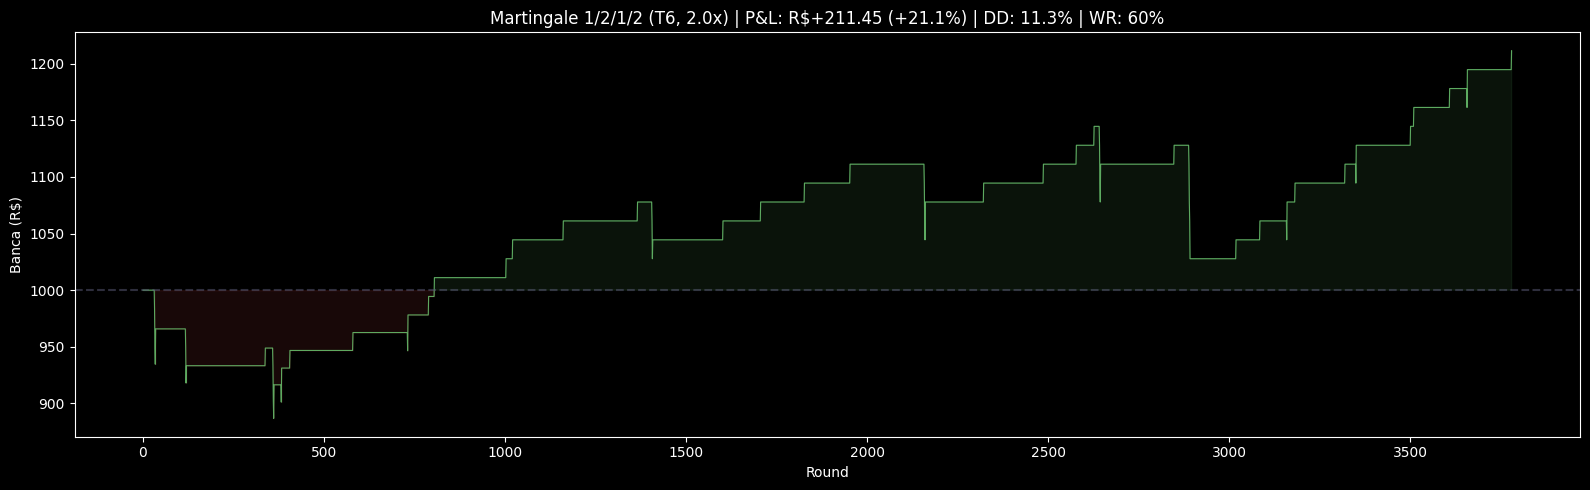

In [7]:
# Testar martingale atual (referência)
config = BankrollConfig(
    initial_bankroll=1000.0,
    base_bet_pct=0.0167,  # banca/6 ≈ 1.67%
    compound=False,
    stop_gain_pct=0.20,   # 20%
    stop_loss_pct=1.00,   # 100% (sem stop loss)
)

# Setup atual: 1/2 + 1/2 (4 dobras, 2 ciclos)
strategy = MartingaleStrategy(
    trigger=6, target=2.0,
    pattern=[1, 2, 1, 2],  # 1/2 + 1/2
)

result = backtest(strategy, multipliers, config)
print(result.summary())

fig, ax = plt.subplots(figsize=(16, 5))
plot_equity_curve(result, ax)
plt.tight_layout()
plt.show()

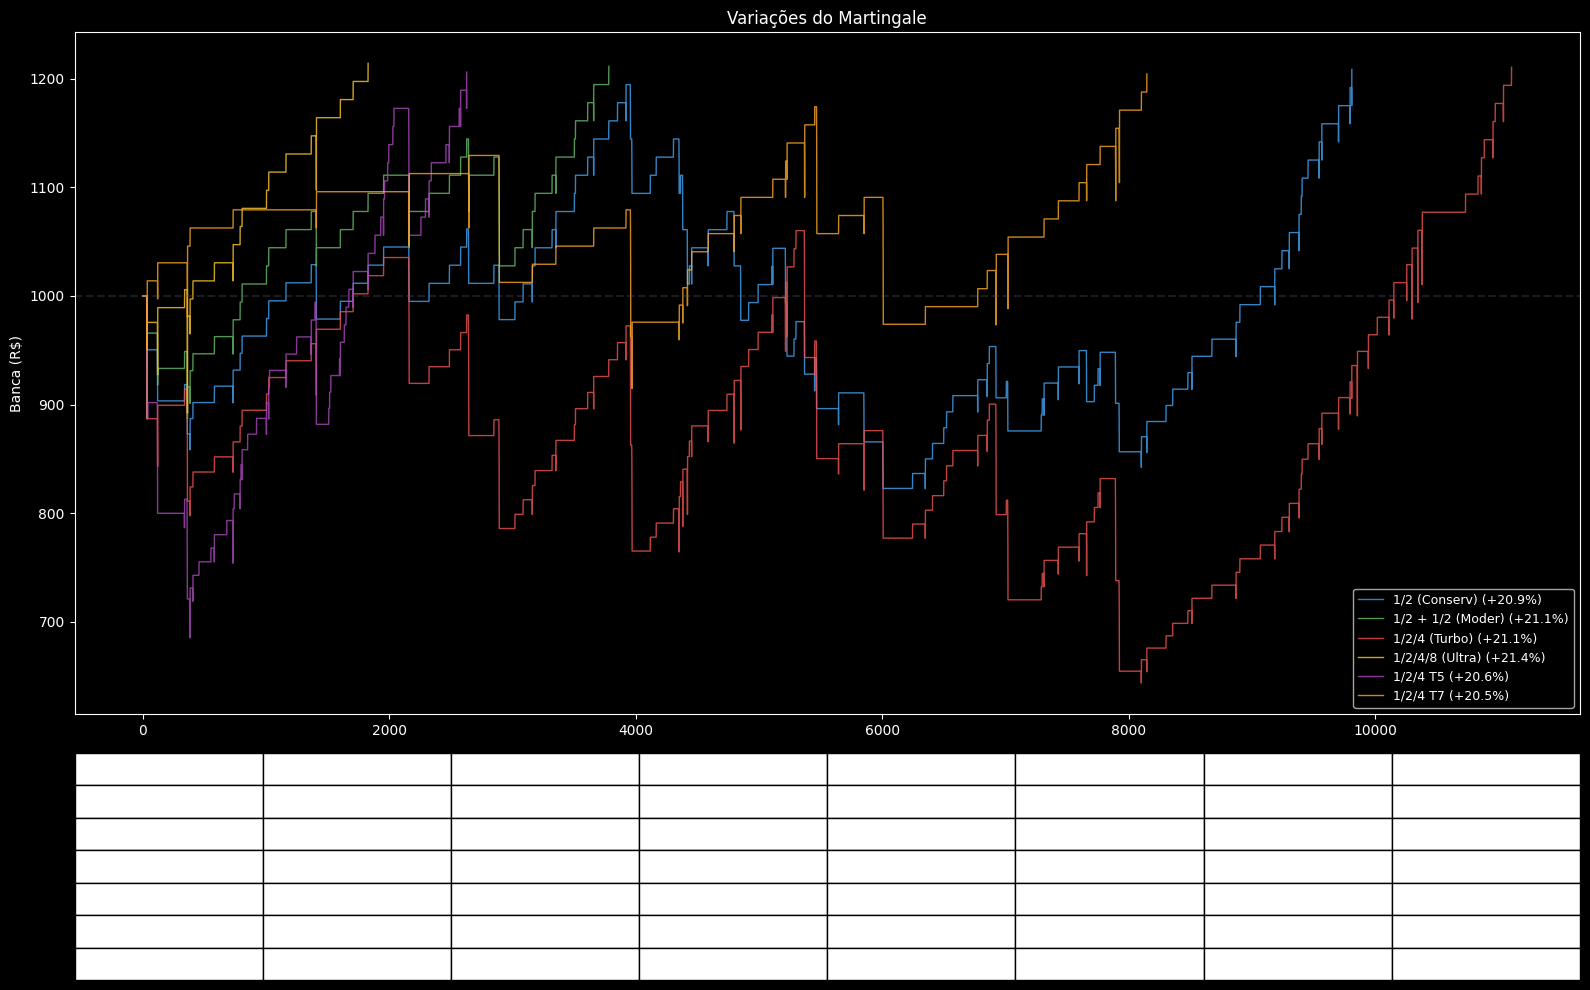

In [8]:
# Testar variações do martingale
configs = [
    ('1/2 (Conserv)', [1, 2], 6),
    ('1/2 + 1/2 (Moder)', [1, 2, 1, 2], 6),
    ('1/2/4 (Turbo)', [1, 2, 4], 6),
    ('1/2/4/8 (Ultra)', [1, 2, 4, 8], 6),
    ('1/2/4 T5', [1, 2, 4], 5),
    ('1/2/4 T7', [1, 2, 4], 7),
]

results = []
for name, pattern, trigger in configs:
    strategy = MartingaleStrategy(trigger=trigger, target=2.0, pattern=pattern)
    r = backtest(strategy, multipliers, config)
    results.append(r)
    # Override name for clarity
    r.strategy_name = name

plot_comparison(results, 'Variações do Martingale')

## 6. Exportar Framework

As classes `BettingStrategy`, `BankrollConfig`, `backtest()` e `plot_*` serão importadas nos próximos notebooks.

In [9]:
print("Framework do backtester pronto!")
print(f"")
print(f"Para usar nos próximos notebooks:")
print(f"  %run 12_backtester.ipynb")
print(f"")
print(f"Ou copie as classes BettingStrategy, BankrollConfig, backtest(), plot_*")

Framework do backtester pronto!

Para usar nos próximos notebooks:
  %run 12_backtester.ipynb

Ou copie as classes BettingStrategy, BankrollConfig, backtest(), plot_*


## 7. Flat Bet Baseline

Comparação entre aposta fixa (sem martingale) e o Moderado (1/2+1/2).
Sem um baseline flat-bet, não sabemos se o martingale agrega valor ou apenas redistribui risco.

FLAT BET vs MARTINGALE (Moderado 1/2+1/2)

--- Flat Bet (T6, 2.0x) ---
Banca: R$1000 → R$1215.68 (+21.6%)
Apostas: 35 (68.6% win rate)
Profit Factor: 2.18
Max Drawdown: 5.0% (R$49.53)
Sharpe Ratio: 0.400
Max Losses Seguidas: 2
Rounds analisados: 3,964,265
  Wins: 24, Losses: 11
  Avg Win: R$16.58, Avg Loss: R$16.57

--- Martingale 1/2/1/2 (T6, 2.0x) ---
Banca: R$1000 → R$1211.45 (+21.1%)
Apostas: 62 (59.7% win rate)
Profit Factor: 1.39
Max Drawdown: 11.3% (R$116.90)
Sharpe Ratio: 0.156
Max Losses Seguidas: 4
Rounds analisados: 3,964,265
  Wins: 37, Losses: 25
  Avg Win: R$20.33, Avg Loss: R$21.63


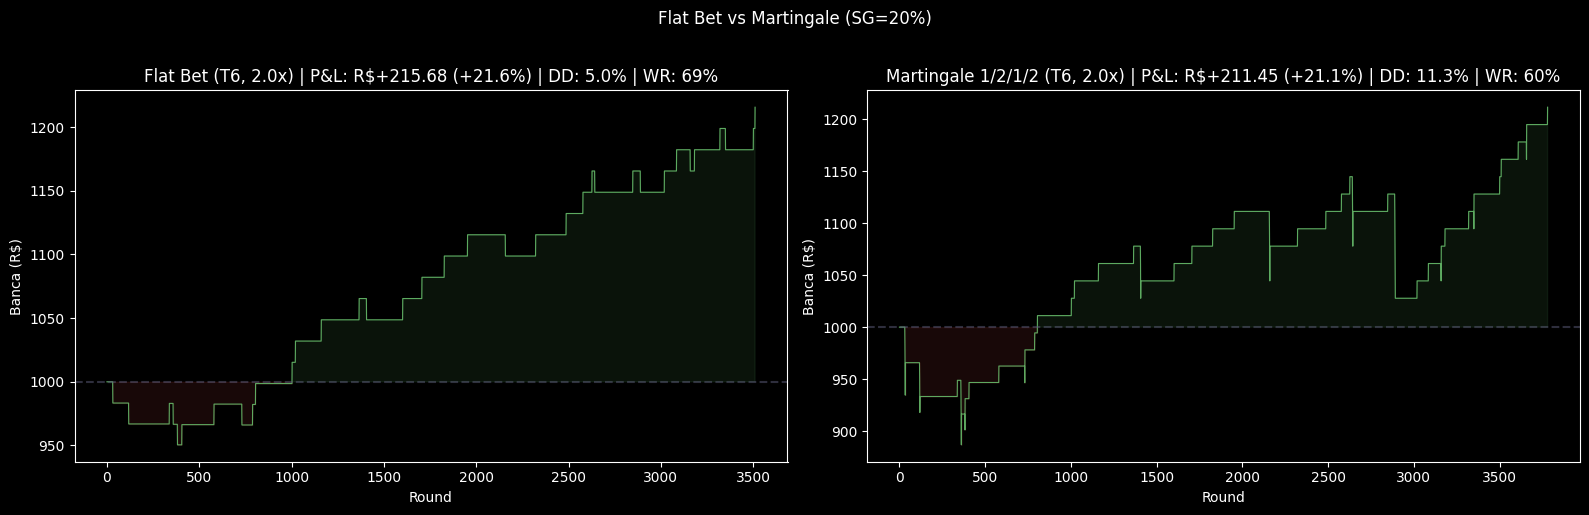

In [10]:
class FlatBetStrategy(BettingStrategy):
    """Aposta fixa (sem martingale) quando trigger ativa. Baseline."""

    def __init__(self, trigger: int = 6, target: float = 2.0):
        self.trigger = trigger
        self.target = target
        self.reset()

    @property
    def name(self) -> str:
        return f"Flat Bet (T{self.trigger}, {self.target}x)"

    def reset(self):
        self.consecutive_lows = 0
        self.awaiting_result = False

    def on_round(self, multiplier, bankroll, base_bet, round_idx):
        is_low = multiplier < LOW_THRESHOLD

        if self.awaiting_result:
            # Resultado resolvido pelo engine
            self.awaiting_result = False
            self.consecutive_lows = 1 if is_low else 0
            return BetDecision(should_bet=False)

        if is_low:
            self.consecutive_lows += 1
        else:
            self.consecutive_lows = 0

        if self.consecutive_lows >= self.trigger:
            self.awaiting_result = True
            self.consecutive_lows = 0
            return BetDecision(should_bet=True, amount=base_bet, target=self.target)

        return BetDecision(should_bet=False)


# Flat bet vs Martingale Moderado
flat = FlatBetStrategy(trigger=6, target=2.0)
mart = MartingaleStrategy(trigger=6, target=2.0, pattern=[1, 2, 1, 2])

r_flat = backtest(flat, multipliers, config)
r_mart = backtest(mart, multipliers, config)

print("=" * 60)
print("FLAT BET vs MARTINGALE (Moderado 1/2+1/2)")
print("=" * 60)

for r in [r_flat, r_mart]:
    print(f"\n{r.summary()}")
    print(f"  Wins: {r.total_wins}, Losses: {r.total_losses}")
    print(f"  Avg Win: R${r.avg_win:.2f}, Avg Loss: R${r.avg_loss:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_equity_curve(r_flat, axes[0])
plot_equity_curve(r_mart, axes[1])
plt.suptitle("Flat Bet vs Martingale (SG=20%)", y=1.02)
plt.tight_layout()
plt.show()

## 8. Impacto do Target (1.5x vs 1.8x vs 1.95x vs 2.0x)

A analise do NB-11 mostrou house edge variavel por target:
- 1.5x: 2.0% edge (melhor)
- 2.0x: 9.1% edge (pior entre targets baixos)

O bot real usa ~1.95x. Qual o impacto no backtest?

Target 1.5x: P&L=R$+206.62 | DD=17.1% | WR=68% | Bets=203 | Sharpe=0.068
Target 1.8x: P&L=R$+201.55 | DD=5.6% | WR=73% | Bets=33 | Sharpe=0.355


Target 1.95x: P&L=R$+204.16 | DD=11.6% | WR=60% | Bets=65 | Sharpe=0.148
Target 2.0x: P&L=R$+211.45 | DD=11.3% | WR=60% | Bets=62 | Sharpe=0.156
Target 2.5x: P&L=R$+207.04 | DD=8.4% | WR=53% | Bets=32 | Sharpe=0.231


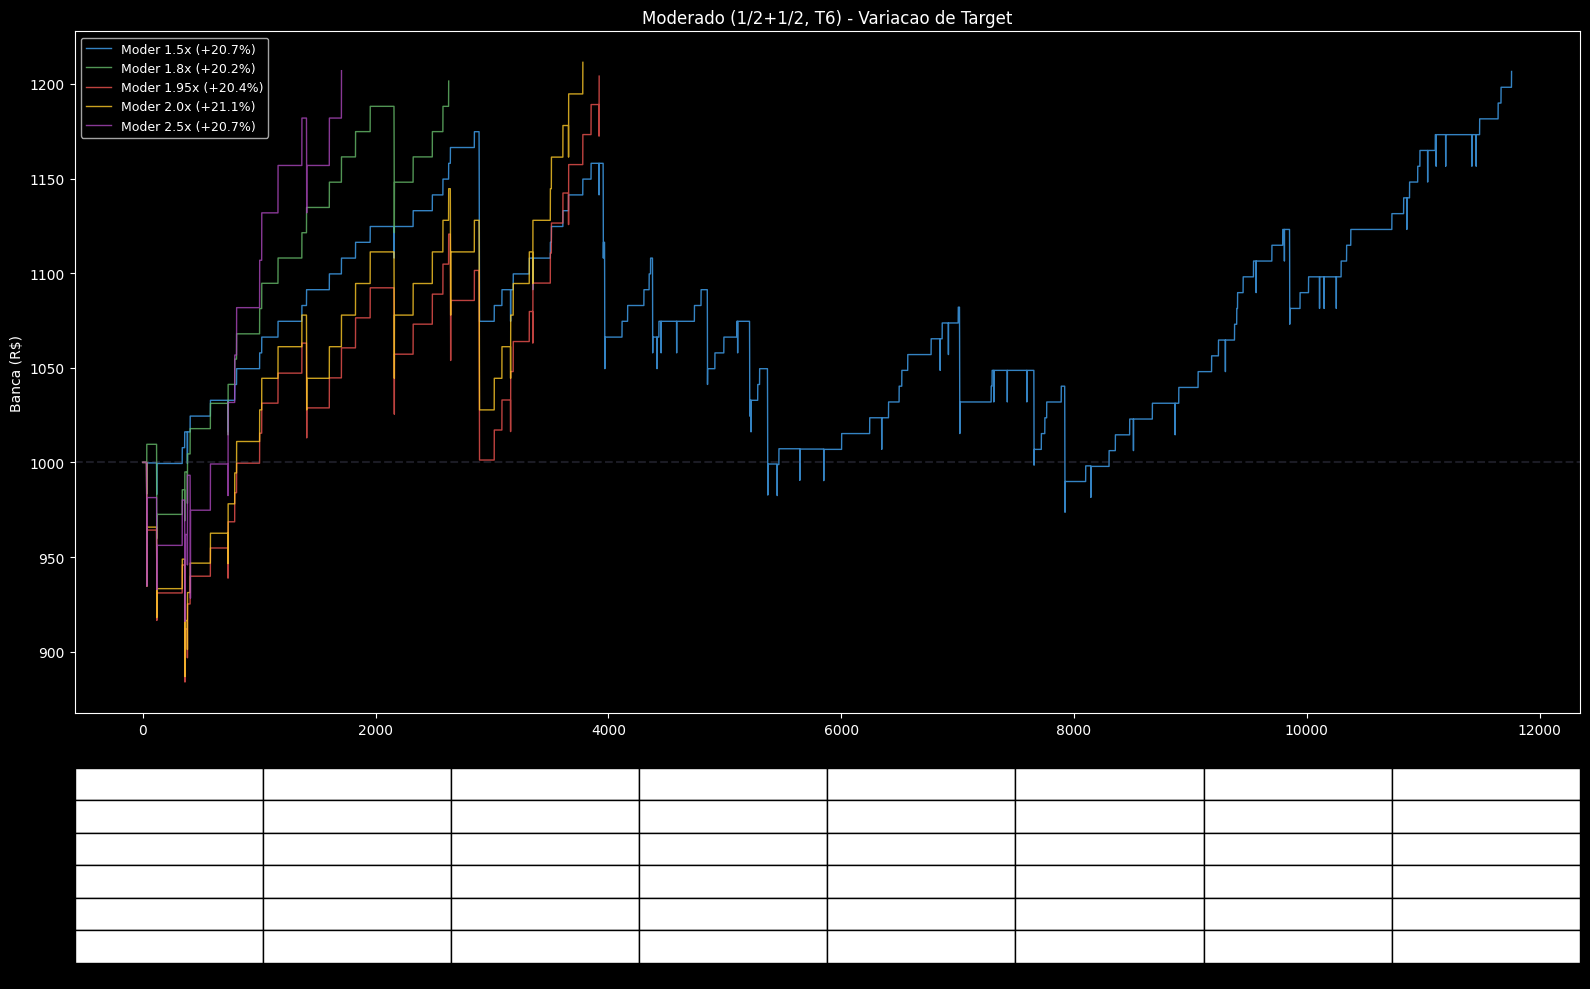

In [11]:
targets = [1.5, 1.8, 1.95, 2.0, 2.5]
target_results = []

for target in targets:
    strategy = MartingaleStrategy(trigger=6, target=target, pattern=[1, 2, 1, 2])
    r = backtest(strategy, multipliers, config)
    r.strategy_name = f"Moder {target}x"
    target_results.append(r)
    print(f"Target {target}x: P&L=R${r.total_profit:+.2f} | "
          f"DD={r.max_drawdown_pct:.1f}% | WR={r.win_rate:.0f}% | "
          f"Bets={r.total_bets} | Sharpe={r.sharpe_ratio:.3f}")

plot_comparison(target_results, 'Moderado (1/2+1/2, T6) - Variacao de Target')

## 9. Longo Prazo sem Stop Gain

Rodando 3.9M rounds SEM stop gain para ver a equity curve real.
O teste anterior com SG=20% apenas mede "caminho ate +20%", nao sustentabilidade.

Flat Bet: Final=R$70563.52 (+6956.4%) | DD=94.0% | Bets=49399


1/2+1/2 (Moder): Final=R$211571.23 (+21057.1%) | DD=29.2% | Bets=85656


1/2/4 (Turbo): Final=R$246333.34 (+24533.3%) | DD=39.3% | Bets=81367


1/2/4/8 (Ultra): Final=R$332009.98 (+33101.0%) | DD=31.1% | Bets=85656


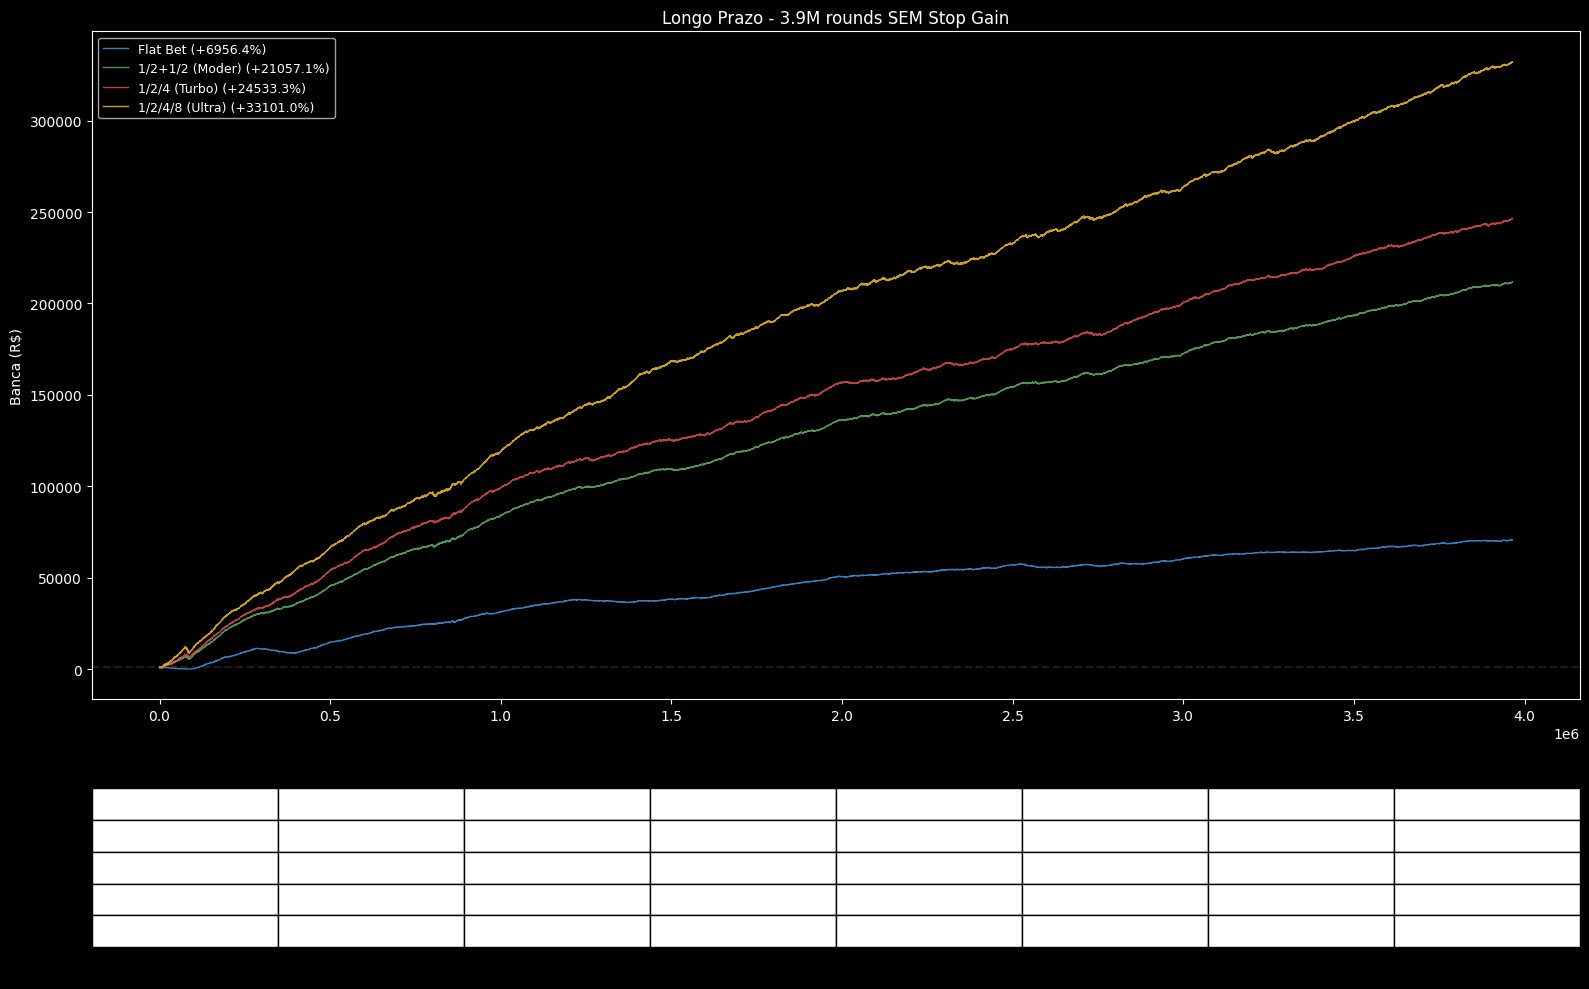

In [12]:
config_no_sg = BankrollConfig(
    initial_bankroll=1000.0,
    base_bet_pct=0.0167,
    compound=False,
    stop_gain_pct=100.0,    # Sem stop gain
    stop_loss_pct=1.00,
)

long_configs = [
    ('Flat Bet', FlatBetStrategy, {'trigger': 6, 'target': 2.0}),
    ('1/2+1/2 (Moder)', MartingaleStrategy, {'trigger': 6, 'target': 2.0, 'pattern': [1, 2, 1, 2]}),
    ('1/2/4 (Turbo)', MartingaleStrategy, {'trigger': 6, 'target': 2.0, 'pattern': [1, 2, 4]}),
    ('1/2/4/8 (Ultra)', MartingaleStrategy, {'trigger': 6, 'target': 2.0, 'pattern': [1, 2, 4, 8]}),
]

long_results = []
for name, cls, kwargs in long_configs:
    strategy = cls(**kwargs)
    r = backtest(strategy, multipliers, config_no_sg)
    r.strategy_name = name
    long_results.append(r)
    print(f"{name}: Final=R${r.final_bankroll:.2f} ({r.total_profit_pct:+.1f}%) | "
          f"DD={r.max_drawdown_pct:.1f}% | Bets={r.total_bets}")

plot_comparison(long_results, 'Longo Prazo - 3.9M rounds SEM Stop Gain')

## 10. Analise por Sessoes (Realista)

O bot roda sessoes de 2-8h (~500-2000 rounds). Dividindo 3.9M rounds em
sessoes de 1000 rounds para ver a **distribuicao** de resultados.

Config: SG=20%, SL=50%, banca R$1000.

ANALISE POR SESSOES - Moderado 1/2+1/2 (1000 rounds)
Total sessoes: 3,964

Profit medio:   R$+51.12
Profit mediano: R$+65.38
Desvio padrao:  R$101.90

Sessoes positivas: 2758 (69.6%)
Sessoes negativas: 1206 (30.4%)
Sessoes neutras:   0 (0.0%)

Hit Stop Gain:  324 (8.2%)
Hit Stop Loss:  0 (0.0%)

Melhor sessao:  R$+216.54
Pior sessao:    R$-413.19

Percentis:
  P05: R$-131.86
  P10: R$-86.14
  P25: R$-18.66
  P50: R$+65.38
  P75: R$+131.29
  P90: R$+183.70
  P95: R$+200.40


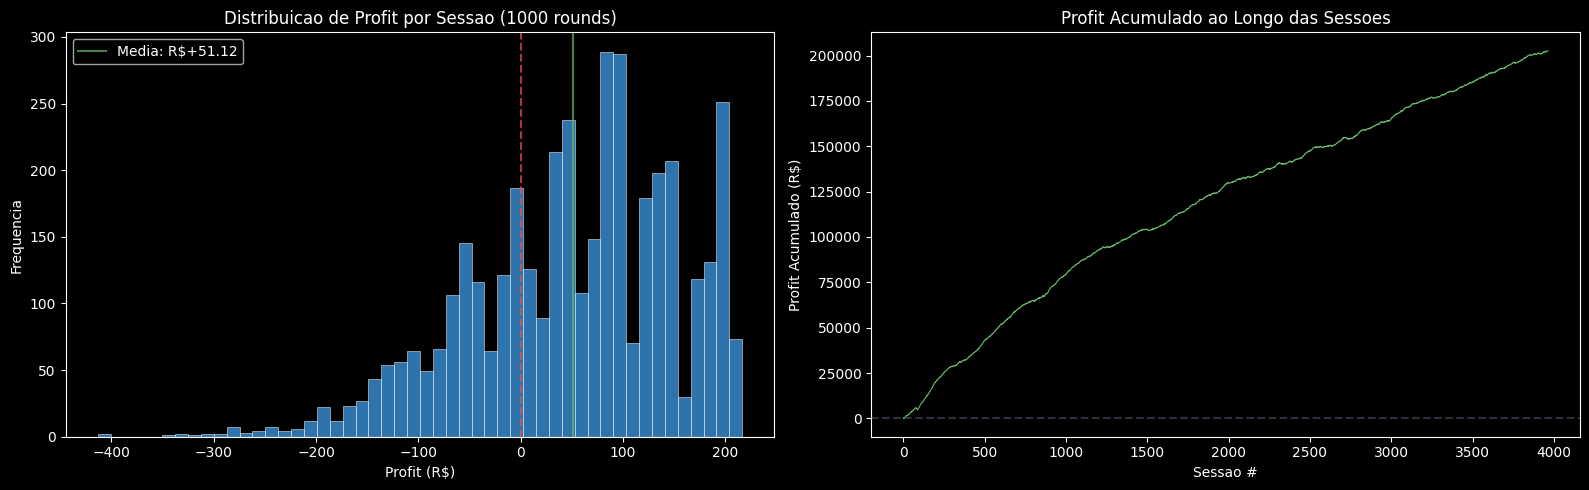

In [13]:
SESSION_SIZE = 1000

def run_session_analysis(strategy_class, strategy_kwargs, session_config,
                         mults=multipliers, session_size=1000):
    """Roda backtest dividido em sessoes independentes."""
    n_sessions = len(mults) // session_size
    profits = []
    hit_sg = 0
    hit_sl = 0

    for i in range(n_sessions):
        start = i * session_size
        end = start + session_size
        session_mults = mults[start:end]

        strategy = strategy_class(**strategy_kwargs)
        result = backtest(strategy, session_mults, session_config)

        profits.append(result.total_profit)

        if result.total_profit_pct >= session_config.stop_gain_pct * 100 * 0.95:
            hit_sg += 1
        if result.total_profit <= -session_config.initial_bankroll * session_config.stop_loss_pct * 0.95:
            hit_sl += 1

    return {
        'profits': np.array(profits),
        'n_sessions': n_sessions,
        'hit_sg': hit_sg,
        'hit_sl': hit_sl,
    }


# Config realista
session_config = BankrollConfig(
    initial_bankroll=1000.0,
    base_bet_pct=0.0167,
    compound=False,
    stop_gain_pct=0.20,
    stop_loss_pct=0.50,
)

# Moderado (1/2+1/2)
sess = run_session_analysis(
    MartingaleStrategy,
    {'trigger': 6, 'target': 2.0, 'pattern': [1, 2, 1, 2]},
    session_config,
    session_size=SESSION_SIZE,
)

profits = sess['profits']
n_sessions = sess['n_sessions']

print("=" * 60)
print(f"ANALISE POR SESSOES - Moderado 1/2+1/2 ({SESSION_SIZE} rounds)")
print("=" * 60)
print(f"Total sessoes: {n_sessions:,}")
print()
print(f"Profit medio:   R${profits.mean():+.2f}")
print(f"Profit mediano: R${np.median(profits):+.2f}")
print(f"Desvio padrao:  R${profits.std():.2f}")
print()
print(f"Sessoes positivas: {(profits > 0).sum()} ({(profits > 0).mean()*100:.1f}%)")
print(f"Sessoes negativas: {(profits < 0).sum()} ({(profits < 0).mean()*100:.1f}%)")
print(f"Sessoes neutras:   {(profits == 0).sum()} ({(profits == 0).mean()*100:.1f}%)")
print()
print(f"Hit Stop Gain:  {sess['hit_sg']} ({sess['hit_sg']/n_sessions*100:.1f}%)")
print(f"Hit Stop Loss:  {sess['hit_sl']} ({sess['hit_sl']/n_sessions*100:.1f}%)")
print()
print(f"Melhor sessao:  R${profits.max():+.2f}")
print(f"Pior sessao:    R${profits.min():+.2f}")
print()
print("Percentis:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    print(f"  P{p:02d}: R${np.percentile(profits, p):+.2f}")

# Graficos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(profits, bins=50, color=COLORS['blue'], alpha=0.7,
             edgecolor='white', linewidth=0.5)
axes[0].axvline(x=0, color=COLORS['red'], linestyle='--', alpha=0.7)
axes[0].axvline(x=profits.mean(), color=COLORS['green'], linestyle='-',
                alpha=0.7, label=f"Media: R${profits.mean():+.2f}")
axes[0].set_title(f'Distribuicao de Profit por Sessao ({SESSION_SIZE} rounds)')
axes[0].set_xlabel('Profit (R$)')
axes[0].set_ylabel('Frequencia')
axes[0].legend()

cumulative = np.cumsum(profits)
axes[1].plot(cumulative, color=COLORS['green'], linewidth=0.8)
axes[1].axhline(y=0, color=COLORS['dim'], linestyle='--', alpha=0.5)
axes[1].set_title('Profit Acumulado ao Longo das Sessoes')
axes[1].set_xlabel('Sessao #')
axes[1].set_ylabel('Profit Acumulado (R$)')

plt.tight_layout()
plt.show()

Estrategia            Media  Mediana      Std   Win%    SG%    SL%       Pior
----------------------------------------------------------------------------------


Flat Bet             +17.33   +16.13    62.74  55.3%   0.6%   0.0%    -197.52


1/2+1/2 Moder        +51.12   +65.38   101.90  69.6%   8.2%   0.0%    -413.19


1/2/4 Turbo          +57.23   +77.60   130.74  68.8%  20.0%   0.1%    -510.97


Moder 1.5x           +23.93   +32.83    58.10  69.5%   0.0%   0.0%    -318.77


Moder 1.95x          +49.90   +64.88    98.12  72.1%   5.9%   0.0%    -422.20


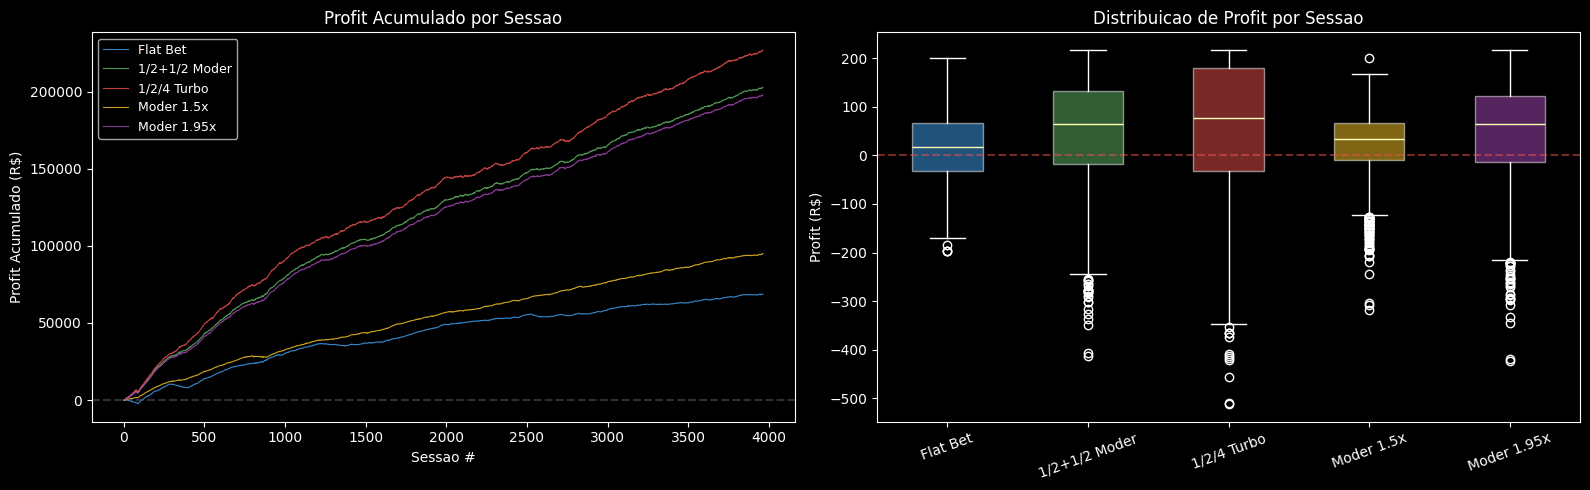

In [14]:
# Comparar estrategias por sessao
strategies_to_test = [
    ('Flat Bet', FlatBetStrategy, {'trigger': 6, 'target': 2.0}),
    ('1/2+1/2 Moder', MartingaleStrategy, {'trigger': 6, 'target': 2.0, 'pattern': [1, 2, 1, 2]}),
    ('1/2/4 Turbo', MartingaleStrategy, {'trigger': 6, 'target': 2.0, 'pattern': [1, 2, 4]}),
    ('Moder 1.5x', MartingaleStrategy, {'trigger': 6, 'target': 1.5, 'pattern': [1, 2, 1, 2]}),
    ('Moder 1.95x', MartingaleStrategy, {'trigger': 6, 'target': 1.95, 'pattern': [1, 2, 1, 2]}),
]

print(f"{'Estrategia':<18} {'Media':>8} {'Mediana':>8} {'Std':>8} "
      f"{'Win%':>6} {'SG%':>6} {'SL%':>6} {'Pior':>10}")
print("-" * 82)

session_data = {}
for name, cls, kwargs in strategies_to_test:
    sr = run_session_analysis(cls, kwargs, session_config, session_size=SESSION_SIZE)
    p = sr['profits']
    session_data[name] = sr
    win_pct = (p > 0).mean() * 100
    sg_pct = sr['hit_sg'] / sr['n_sessions'] * 100
    sl_pct = sr['hit_sl'] / sr['n_sessions'] * 100
    print(f"{name:<18} {p.mean():>+8.2f} {np.median(p):>+8.2f} {p.std():>8.2f} "
          f"{win_pct:>5.1f}% {sg_pct:>5.1f}% {sl_pct:>5.1f}% {p.min():>+10.2f}")

# Graficos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_list = [COLORS['blue'], COLORS['green'], COLORS['red'],
               COLORS['yellow'], COLORS['purple']]

for i, (name, _, _) in enumerate(strategies_to_test):
    cumul = np.cumsum(session_data[name]['profits'])
    axes[0].plot(cumul, color=colors_list[i], linewidth=0.8, alpha=0.8, label=name)

axes[0].axhline(y=0, color=COLORS['dim'], linestyle='--', alpha=0.5)
axes[0].set_title('Profit Acumulado por Sessao')
axes[0].set_xlabel('Sessao #')
axes[0].set_ylabel('Profit Acumulado (R$)')
axes[0].legend(fontsize=9)

# Box plot
all_profits = [session_data[name]['profits'] for name, _, _ in strategies_to_test]
names = [name for name, _, _ in strategies_to_test]
bp = axes[1].boxplot(all_profits, labels=names, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[1].axhline(y=0, color=COLORS['red'], linestyle='--', alpha=0.5)
axes[1].set_title('Distribuicao de Profit por Sessao')
axes[1].set_ylabel('Profit (R$)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()